In [71]:
import os
import cv2
import torch
import numpy as np
from tqdm import tqdm

from PIL import Image
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix


import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset, DataLoader

## Device

In [72]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

## Load DinoV2

In [73]:
dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dinov2_vits14 = dinov2_vits14.to(device)

ROOT_PATH = '/media/osero/SamsungSSD/CMPE_SSD/frame-hand_left-c256_TOY/'

Using cache found in /home/osero/.cache/torch/hub/facebookresearch_dinov2_main


## Prepare Dataset

In [74]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [75]:

def create_label_dict(classes):
    label_dict = {}
    for i in range(0,len(classes)):
        label_dict[classes[i]] = i
    return label_dict


In [76]:
####### SECOND #######

import os
import pickle
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image

class CustomImageDataset(Dataset):
    def __init__(self, pickle_dir, transform=None):
        self.pickle_dir = pickle_dir
        self.transform = transform
        
        pickle_file = open(pickle_dir, 'rb')
        features,labels = pickle.load(pickle_file)
        self.features = features
        self.classes = np.unique(labels)
        label_dict = create_label_dict(self.classes)
        self.labels = [label_dict[x] for x in labels]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        frame_frequency = 8
        sampled_features = self.features[idx][0::frame_frequency]
        average_features = np.mean(sampled_features, axis=0)
        tensor = torch.from_numpy(average_features)
        return tensor, self.labels[idx]  # Returning image and its path

In [102]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset


def train_val_dataset(dataset, val_split=0.2):
    train_idx, val_idx = train_test_split(list(range(len(dataset))), test_size=val_split)
    datasets = {}
    datasets['train'] = Subset(dataset, train_idx)
    datasets['test'] = Subset(dataset, val_idx)
    return datasets

custom_dataset = CustomImageDataset('/media/osero/SamsungSSD/pickles/features_right_hand_frames_325.pickle') 
image_datasets = train_val_dataset(custom_dataset)

# image_datasets = {
#     x: CustomImageDataset('/media/osero/SamsungSSD/pickles/features_left_hand_frames_288.pickle') 
#     for x in ['train', 'test']
# }
# image_datasets

# train_dataset, validation_dataset = torch.utils.data.random_splitrandom_split(dataset, [train_size, validation_size])
#     x: CustomImageDataset(os.path.join(ROOT_PATH, x), data_transforms[x]) 
#     x: datasets.ImageFolder(os.path.join(ROOT_PATH, x), data_transforms[x]) 


In [103]:
batch_size = 8
num_workers = 4
# data_loaders = {x: DataLoader(image_datasets[x], shuffle=True, batch_size=batch_size, num_workers=4)

data_loaders = {x: DataLoader(image_datasets[x], shuffle=True, batch_size=batch_size)
    for x in ['train', 'test']
}

In [104]:
class_names = image_datasets['train'].dataset.classes
print('Train count: ', len(image_datasets['train'].dataset.labels))
print('Test count: ', len(image_datasets['test'].dataset.labels))
class_names

Train count:  9568
Test count:  9568


array([  8,  10,  12,  15,  17,  18,  19,  21,  22,  23,  25,  28,  29,
        30,  31,  37,  41,  43,  45,  46,  48,  49,  50,  52,  53,  55,
        57,  58,  59,  60,  61,  64,  66,  67,  68,  78,  79,  81,  83,
        85,  86,  89,  91,  93,  94,  98, 102, 103, 108, 109, 112, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 131, 133, 134, 135, 136,
       137, 138, 139, 140, 142, 147, 148, 149, 150, 152, 154, 155, 157,
       158, 159, 160, 161, 162, 163, 164, 165, 167, 169, 170, 172, 177,
       178, 179, 193, 196, 197, 198, 199, 200, 206, 209, 210, 211, 212,
       215, 217, 218, 223, 224, 226, 230, 234, 239, 242, 244, 245, 246,
       248, 249, 250, 251, 252, 253, 258, 263, 266, 267, 272, 278, 279,
       285, 288, 289, 291, 295, 297, 300, 301, 302, 306, 307, 314, 318,
       319, 323, 328, 333, 334, 335, 338, 339, 340, 342, 347, 349, 350,
       352, 354, 355, 356, 359, 364, 367, 368, 370, 371, 372, 374, 378,
       379, 383, 385, 386, 392, 393, 396, 399, 400, 402, 403, 40

## Model

In [105]:
class DinoVisionTransformerClassifier(nn.Module):
    def __init__(self):
        super(DinoVisionTransformerClassifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, len(class_names))
        )
    
    def forward(self, x):
        x = self.classifier(x)
        return x
    
model = DinoVisionTransformerClassifier()
model = model.to(device)

In [106]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

## Train

In [107]:
num_epoch = 100
for epoch in range(num_epoch):
    train_acc = 0
    train_loss = 0
    loop = tqdm(data_loaders['train'])
    for idx, (features, labels) in enumerate(loop):
        features = features.to(device)
        labels = labels.to(device)
        # print('features.shape: ', features.shape)
        # print('labels.shape: ', labels.shape)
        # print('labels: ', labels)
        # print('torch.max(features): ', torch.max(features))
        # print('torch.min(features): ', torch.min(features))
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)

        predictions = outputs.argmax(dim=1, keepdim=True).squeeze()
        correct = (predictions == labels).sum().item()
        accuracy = correct / batch_size

        loss.backward()
        optimizer.step()
        # print(f"Epoch [{epoch}/{num_epoch}], loss: {loss.item()}, accuracy: {accuracy}")

        loop.set_description(f"Epoch [{epoch}/{num_epoch}]")
        loop.set_postfix(loss=loss.item(), acc=accuracy)

Epoch [99/100]: 100%|██████████| 957/957 [00:01<00:00, 491.92it/s, acc=0.625, loss=0.875]


## Test

In [109]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
test_predicted = []
test_labels = []

with torch.no_grad():
    for features, labels in data_loaders["test"]:
        features = features.to(device)
        labels = labels.to(device)

        # calculate outputs by running images through the network
        outputs = model(features)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted.to(device) == labels).sum().item()
        
        test_labels += (labels.cpu().numpy().tolist())
        test_predicted += (predicted.cpu().numpy().tolist())

print(f'Accuracy of the network on the {len(data_loaders["test"])*6} test images: {100 * correct // total} %')

Accuracy of the network on the 1440 test images: 36 %


## Report

In [ ]:
print(classification_report(test_labels, test_predicted, target_names=class_names))


                            precision    recall  f1-score   support

           ABBOTTS BABBLER       1.00      1.00      1.00         5
             ABBOTTS BOOBY       1.00      1.00      1.00         5
ABYSSINIAN GROUND HORNBILL       1.00      1.00      1.00         5
     AFRICAN CROWNED CRANE       1.00      1.00      1.00         5
    AFRICAN EMERALD CUCKOO       1.00      1.00      1.00         5
         AFRICAN FIREFINCH       1.00      1.00      1.00         5
    AFRICAN OYSTER CATCHER       1.00      1.00      1.00         5
     AFRICAN PIED HORNBILL       1.00      1.00      1.00         5
       AFRICAN PYGMY GOOSE       1.00      1.00      1.00         5
                 ALBATROSS       1.00      1.00      1.00         5
            ALBERTS TOWHEE       1.00      1.00      1.00         5
      ALEXANDRINE PARAKEET       1.00      1.00      1.00         5
             ALPINE CHOUGH       1.00      1.00      1.00         5
     ALTAMIRA YELLOWTHROAT       1.00      1.00

In [ ]:
cm = confusion_matrix(test_labels, test_predicted)
df_cm = pd.DataFrame(
    cm, 
    index = class_names,
    columns = class_names
)
df_cm

,ABBOTTS BABBLER,ABBOTTS BOOBY,ABYSSINIAN GROUND HORNBILL,AFRICAN CROWNED CRANE,AFRICAN EMERALD CUCKOO,AFRICAN FIREFINCH,AFRICAN OYSTER CATCHER,AFRICAN PIED HORNBILL,AFRICAN PYGMY GOOSE,ALBATROSS,ALBERTS TOWHEE,ALEXANDRINE PARAKEET,ALPINE CHOUGH,ALTAMIRA YELLOWTHROAT,AMERICAN AVOCET,AMERICAN BITTERN,AMERICAN COOT,AMERICAN FLAMINGO,AMERICAN GOLDFINCH,AMERICAN KESTREL
ABBOTTS BABBLER,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ABBOTTS BOOBY,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ABYSSINIAN GROUND HORNBILL,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AFRICAN CROWNED CRANE,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AFRICAN EMERALD CUCKOO,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AFRICAN FIREFINCH,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AFRICAN OYSTER CATCHER,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0
AFRICAN PIED HORNBILL,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0
AFRICAN PYGMY GOOSE,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0
ALBATROSS,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0


/tmp/ipykernel_26973/101969818.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


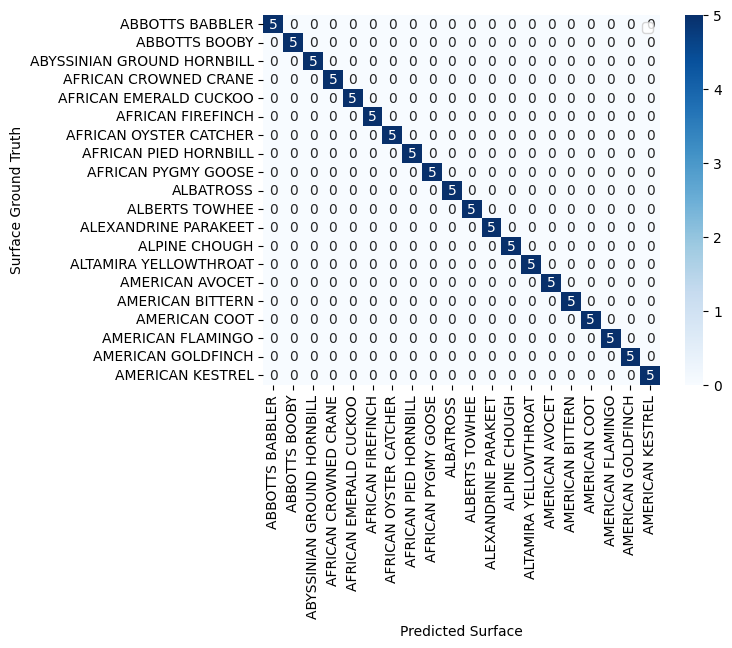

In [ ]:
def show_confusion_matrix(confusion_matrix):
    hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
    plt.ylabel("Surface Ground Truth")
    plt.xlabel("Predicted Surface")
    plt.legend()
    
show_confusion_matrix(df_cm)